In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.ingredients_analysis import plot_ingrs_daily_consumption
from src.LSTM.feature_scaling import apply_scale_to_numerical_features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

,A.1. original sauce,Clove,Refined flour,Salt,Sugar
Date,,,,,
2019-01-01,5.390891,0.097426,27.062706,153.557043,1573.765650
2019-01-02,3.550099,0.064158,17.821782,101.122931,1036.382257
2019-01-03,4.207525,0.076040,21.122112,119.849399,1228.304898
2019-01-04,3.418614,0.061782,17.161716,97.377637,997.997729
2019-01-05,7.100198,0.128317,35.643564,202.245861,2072.764515
...,...,...,...,...,...
2019-06-26,4.076040,0.073663,20.462046,116.104106,1189.920370
2019-06-27,7.231683,0.130693,36.303630,205.991155,2111.149043
2019-06-28,6.311287,0.114059,31.683168,179.774099,1842.457347


categorical_features:  ['DayType']
numerical_features:  ['A.1. original sauce', 'Clove', 'Refined flour', 'Salt', 'Sugar']
( 0  ,  A.1. original sauce )
( 1  ,  Clove )
( 2  ,  Refined flour )
( 3  ,  Salt )
( 4  ,  Sugar )


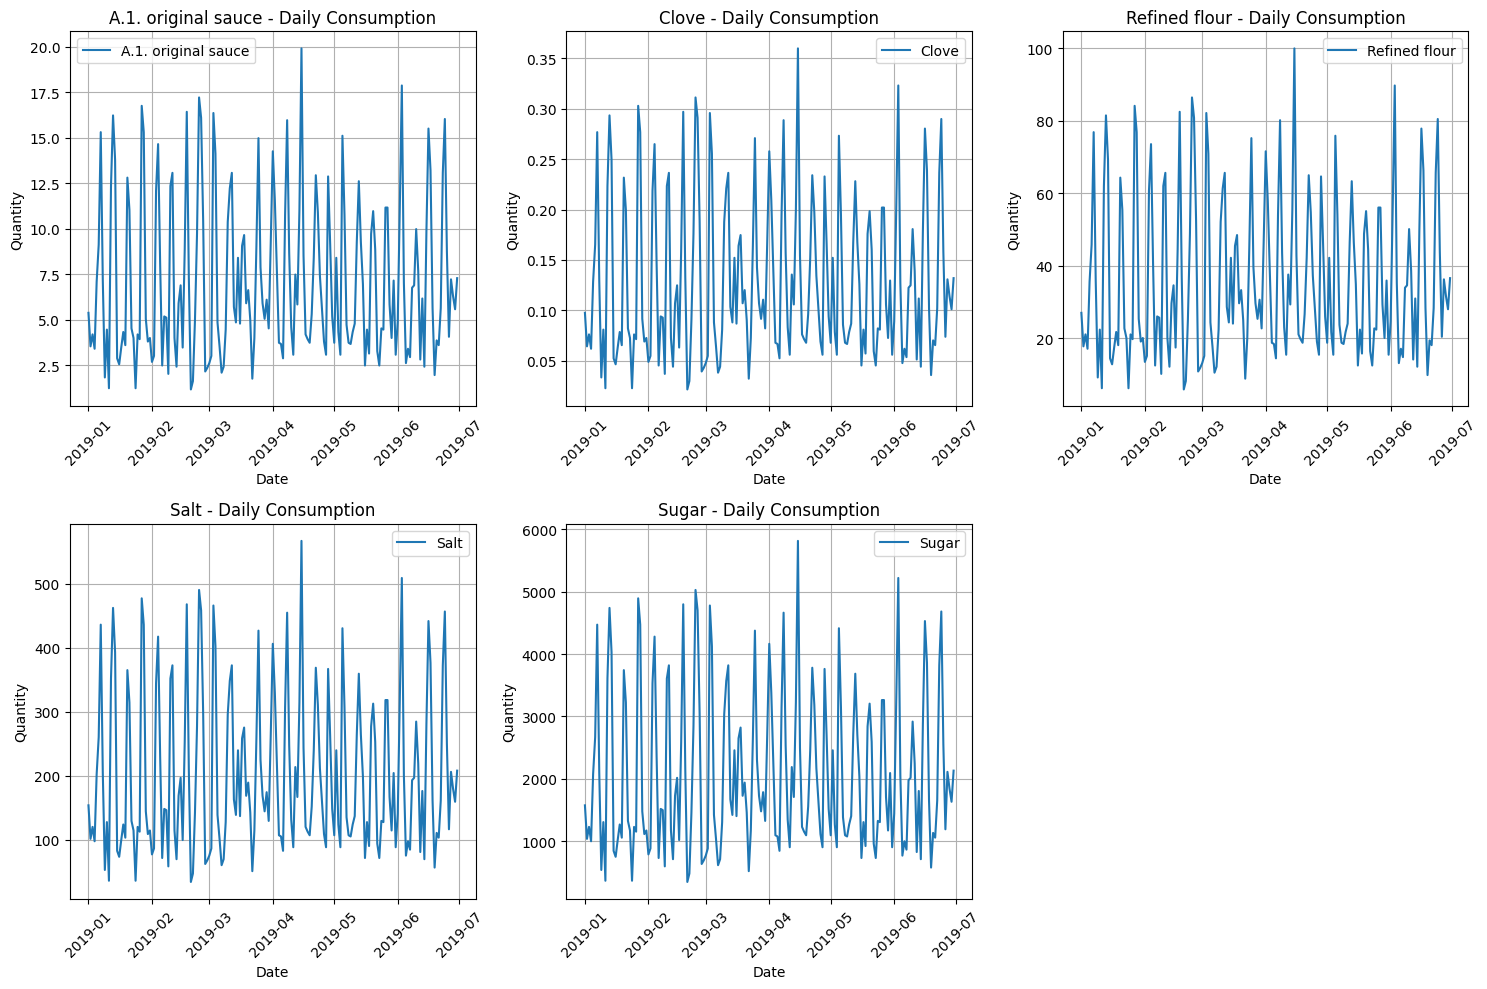

In [2]:
# Restaurant data with the 25 most frequent ingredients
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
display(daily_consumption_df)

# Display categorical and numerical features
categorical_features = ['DayType']
print("categorical_features: ", categorical_features)
numerical_features = [ col for col in daily_consumption_df.columns if col not in categorical_features]
print("numerical_features: ", numerical_features)

# Plot ingredients daily consumption
plot_ingrs_daily_consumption(daily_consumption_df, numerical_features)

##### Scale Categorical and Numerical Features

In [ ]:
# Applying feature scaling to categorical features
#scaled_categorical_df = apply_scale_to_categorical_features(daily_consumption_df, categorical_features)

# Applying feature scaling to numerical features
scaler, scaled_numerical_df = apply_scale_to_numerical_features(daily_consumption_df, numerical_features)

# Combine the scaled numerical data with the original categorical data
#daily_consumption_scaled_df = pd.concat([scaled_categorical_df, scaled_numerical_df], axis=1)
daily_consumption_scaled_df = scaled_numerical_df
display(daily_consumption_scaled_df)

##### Create Lag Features

In [ ]:
from copy import deepcopy as dc

def generate_time_sequences(df, feature_columns, target_columns, window):
    X = []  # input sequences
    y = []  # target values
    time_sequences_df = dc(df)   # Deep copy the dataframe to avoid modifying the original data
    #display(time_sequences_df)

    # Create time-shifted features
    for col in time_sequences_df.columns:
        #print("column: ", col)
        for i in range(1, window + 1):
            time_sequences_df[f'{col}(t-{i})'] = time_sequences_df[col].shift(i)

    # Drop rows with NaN values generated by the shift
    time_sequences_df.dropna(inplace=True)

    # Extract input sequences and target values
    #print("feature_columns: ", feature_columns)
    #print("target_columns: ", target_columns)
    for _, row in time_sequences_df.iterrows():
        sequence = []
        for i in range(window, 0, -1):
            sequence.append([row[f'{col}(t-{i})'] for col in feature_columns])
        X.append(sequence)
        y.append([row[target.capitalize()] for target in target_columns])

    return time_sequences_df, np.array(X), np.array(y)

print()

window = 4
feature_columns = daily_consumption_scaled_df.columns
target_columns = numerical_features # type: ignore
(time_sequences_df, X, y) = generate_time_sequences(daily_consumption_scaled_df, feature_columns, target_columns , window)
print("Time-Shifted Features: ")
display(time_sequences_df)
print(f"X numpy: {X.shape}, Dimensions: {X.ndim}")
print(f"y numpy: {y.shape}, Dimensions: {y.ndim}", '\n')


In [ ]:
# Determine the split index for training and testing data - Holdout cross-validation
split_index = int(len(X) * 0.84) 
print("split_index: ", split_index)

# Split the data into training and testing sets
X_train, X_test = X[:split_index], X[split_index:] 
y_train, y_test = y[:split_index], y[split_index:]

print(f"X_test numpy: {X_test.shape}, Dimensions: {X_test.ndim}")

# Convert the numpy arrays to PyTorch tensors
X_train, X_test = torch.tensor(X_train).float(), torch.tensor(X_test).float()
y_train, y_test = torch.tensor(y_train).float(), torch.tensor(y_test).float()

print(f"X_test tensor: {X_test.shape}, Dimensions: {X_test.ndim}")

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
class LSTM(nn.Module):
    '''
    input_size - The number of expected features in the input x
    hidden_size - The number of features in the hidden state h
    num_layers - Number of recurrent layers
    '''
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1) 

        # Fully connected linear layer
        self.fc = nn.Linear(hidden_size, output_size)   

    def forward(self, x):
        batch_size = x.size(0)

        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        # Initialize cell state
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) # Linear layer will map the LSTM output to the desired output size
        return out
    

features_number = len(feature_columns)
print("features_number: ", features_number)
hidden_size = 50
num_stack_layers = 2
output_size = len(target_columns)
print("output_size: ", output_size)

print("Creating LSTM model ...")
model = LSTM(features_number, hidden_size, num_stack_layers, output_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)

In [ ]:
import torch.optim as optim

def train_loop(dataloader, model, loss_fn, optimizer, device):
    model.train()   # Set the model to training mode
    
    num_batches = len(dataloader)   # Number of total batches
    train_loss = 0.0
    train_predictions = []
    train_actuals = []

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()   # Reset the gradients of model parameters
        # Compute prediction and loss
        prediction = model(X_batch)
        loss = loss_fn(prediction, y_batch)
        loss.backward()     # Determine the gradients for this loop 
        optimizer.step()    # Adjust the parameters by the gradients collected in the backward pass.

        train_loss += loss.item()   # sum all the train losses

        with torch.no_grad():
            train_predictions.extend(prediction.cpu().detach().numpy())
            train_actuals.extend(y_batch.cpu().detach().numpy())
    
    train_loss /= num_batches  # average loss of each epoch
    return train_loss, train_predictions, train_actuals

def test_loop(dataloader, model, loss_fn, device):
    model.eval()    # Set the model to evaluation mode

    num_batches = len(dataloader)   # Number of total batches 
    test_loss = 0.0
    test_predictions = []
    test_actuals = []

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            prediction = model(X_batch)
            loss = loss_fn(prediction, y_batch)
            test_loss += loss.item()    # sum all the test losses

            test_predictions.extend(prediction.cpu().detach().numpy())
            test_actuals.extend(y_batch.cpu().detach().numpy())

    test_loss /= num_batches
    return test_loss, test_predictions, test_actuals


# Hyperparameters
learning_rate = 0.001
num_epochs = 50 #!! LATER : Find the best epoch 

# Initialize model, loss function, and optimizer
#loss_function = nn.MSELoss()
loss_function = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

# Training and evaluation
print("\n", "------------ LSTM Model Training & Evaluations Results ------------", "\n")

best_loss = float('inf') 
best_train_pred, train_actuals = [], []
best_test_pred, test_actuals = [], []

train_hist =[]
test_hist =[]

for epoch in range(num_epochs):
    # Training phase
    train_loss, train_predictions, train_actuals = train_loop(train_dataloader, model, loss_function, optimizer, device)
    train_hist.append(train_loss)
    # Validation phase
    val_loss, test_predictions, test_actuals = test_loop(test_dataloader, model, loss_function, device)
    test_hist.append(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss}, Val Loss: {val_loss}')

    # Update best_loss and possibly save model
    if val_loss < best_loss: 
        best_loss = val_loss
        print("Best loss updated: ", best_loss, "\n")
        best_train_pred = train_predictions
        train_actuals = train_actuals
        best_test_pred = test_predictions
        test_actuals = test_actuals
print("\nDone!")

#### Plotting the Learning Curve

In [ ]:
x = np.linspace(1,num_epochs,num_epochs)
plt.plot(x,train_hist,scalex=True, label="Training loss")
plt.plot(x, test_hist, label="Test loss")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import root_mean_squared_error


def denormalize(scaler, data):
    """Utility function to denormalize data using the provided scaler."""
    return scaler.inverse_transform(data)

def get_denormalize_results(predictions, actuals, scaler):
    """ """
    # Convert to numpy arrays for easier manipulation
    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # Denormalize the predictions and actuals
    predictions_denorm = denormalize(scaler, predictions)
    actuals_denorm = denormalize(scaler, actuals)

    return predictions_denorm, actuals_denorm

def plot_ingredient_results(train_predictions, train_actuals, test_predictions, test_actuals, title, ingr_idx):
    """ """
    plt.figure(figsize=(15, 6))  # Adjust figure size for side-by-side plots

    # Create a grid of subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # # Training data
    # ingr_train_pred = train_predictions[:, ingr_idx].reshape(-1, 1)
    # ingr_train_actuals = train_actuals[:, ingr_idx].reshape(-1, 1)
    
    ax1.plot(train_actuals, label='Actual')
    ax1.plot(train_predictions, label='Predicted')
    ax1.set_title(f'{title} - Training Data Actual vs Predicted')
    ax1.set_xlabel('Day')
    ax1.set_ylabel('Quantity')
    ax1.legend()
    ax1.grid(True)
    
    # Testing data
    # ingr_test_pred = test_predictions[:, ingr_idx].reshape(-1, 1)
    # ingr_test_actuals = test_actuals[:, ingr_idx].reshape(-1, 1)
    
    ax2.plot(test_actuals, label='Actual')
    ax2.plot(test_predictions, label='Predicted')
    ax2.set_title(f'{title} - Testing Data Actual vs Predicted')
    ax2.set_xlabel('Day')
    ax2.set_ylabel('Quantity')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def calculate_rmse(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    return rmse

def calculate_mape(y_true, y_pred):
    # Avoid division by zero by adding a small constant where y_true is zero
    epsilon = 1e-10
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    return mape

In [ ]:
train_predictions, train_actuals = get_denormalize_results(best_train_pred, train_actuals, scaler)
test_predictions, test_actuals = get_denormalize_results(best_test_pred, test_actuals, scaler)

for idx, ingredient in enumerate(target_columns):
    print("(", idx," , ", ingredient,")")
    # Training data
    ingr_train_pred = train_predictions[:, idx].reshape(-1, 1)
    ingr_train_actuals = train_actuals[:, idx].reshape(-1, 1)
    # Testing data
    ingr_test_pred = test_predictions[:, idx].reshape(-1, 1)
    ingr_test_actuals = test_actuals[:, idx].reshape(-1, 1)

    ingr_rmse = calculate_rmse(ingr_train_actuals, ingr_train_pred)
    print(f'{ingredient} RMSE: ', ingr_rmse)
    ingr_mape = calculate_mape(ingr_train_actuals, ingr_train_pred)
    print(f'{ingredient} MAPE: ', ingr_mape)

    plot_ingredient_results(ingr_train_pred, ingr_train_actuals, ingr_test_pred, ingr_test_actuals, ingredient, idx)

#### Short-Term Forecast (Next 9 Days of July 2019)

In [ ]:
def generate_forecast_dates(orignal_dates_df, number_of_forecast_days, number_of_future_days):
    ''' '''
    # Get the last date
    last_date = orignal_dates_df[-1]

    # Generate the next 9 future dates
    future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=number_of_future_days)
    
    # Concatenate the original index with the future dates
    forecast_dates = orignal_dates_df.append(future_dates)

    # Convert to DatetimeIndex and normalize the dates
    forecast_dates = pd.DatetimeIndex(forecast_dates).normalize()

    # Select only the forecasted range
    forecast_dates = forecast_dates[-number_of_forecast_days:]

    return forecast_dates

def generate_future_daytypes(future_dates_df):
    weekend_days = ['Saturday', 'Sunday']
    future_daytypes = []
    
    for date in future_dates_df:
        # Get the day of the week as a string
        day_of_week = date.strftime('%A')
        
        if day_of_week in weekend_days:
            future_daytypes.append(1)
        else:
            future_daytypes.append(0)

    return future_daytypes

In [ ]:
forecast_dates = generate_forecast_dates(daily_consumption_df.index[window:], 18, 9) # type: ignore

future_daytypes = generate_future_daytypes(forecast_dates[-9:])

In [ ]:
# Define the number of future time steps to forecast
num_forecast_steps = 9

# Convert to NumPy and remove singleton dimensions
sequence_to_plot = X_test.squeeze().cpu().numpy()   # Dimensions: 3
print(f"sequence_to_plot: {sequence_to_plot.shape}, Dimensions: {sequence_to_plot.ndim}")
  
# Use the last 9 data points as the starting point # June last day
#historical_data = sequence_to_plot[-1] # Dimensions: 2
historical_data = sequence_to_plot[27]
print(f"historical_data: {historical_data.shape}, Dimensions: {historical_data.ndim}")
 
# Initialize a list to store the forecasted values
forecasted_values = []

# Forecast Dates 
forecast_dates = generate_forecast_dates(daily_consumption_df.index[window:], 18, 9) # type: ignore

# Future Day Types generated
future_daytypes = generate_future_daytypes(forecast_dates[-9:]) # type: ignore
display(future_daytypes)
# Forecast Day Types 
forecast_daytypes = daily_consumption_scaled_df[-9:]['DayType'].to_list() + future_daytypes
display(forecast_daytypes)

# Use the trained model to forecast future values (9 last days and 9 future days)
with torch.no_grad():
    for idx in range(num_forecast_steps*2):
        #print("\nIteration ", idx)
       #print(f"historical_data shape: {historical_data.shape}, Dimensions: {historical_data.ndim}")
        # Prepare the historical_data tensor todimension 3
        historical_data_tensor = torch.tensor(historical_data).reshape(1, window, features_number).float().to(device)
        #print("Historical_data Tensor: ")
        #display(historical_data_tensor)
        #print(f"historical_data tensor: {historical_data_tensor.shape}, Dimensions: {historical_data_tensor.ndim}")

        # Determine the next day type based on historical data
        # daytype = determine_next_daytype(historical_data_tensor)
        # print("daytype: ", daytype)

        # Use the model to predict the next value
        prediction = model(historical_data_tensor)
        #print("Predicted values: ")
        #display(prediction)

        prediction_to_numpy = prediction[0].cpu().numpy()
        #print(f"predictions_to_numpy: {prediction_to_numpy.shape}, Dimensions: {prediction_to_numpy.ndim}")

        # Append the predicted value to the forecasted_values list
        forecasted_values.append(prediction_to_numpy)
        #print("Forecasted_values: ")
        #display(forecasted_values)

        # Update the historical_data sequence by removing the oldest value and adding the predicted value
        historical_data = np.roll(historical_data, shift=-1, axis=0)
        #historical_data[-1] = prediction_to_numpy
        historical_data[-1] = np.insert(prediction_to_numpy, 0, forecast_daytypes[idx])
        #print("new historical_data: ")
        #print(historical_data)

In [ ]:
def plot_ingredient_forecasts(ingr, original_time_steps, real_quantities, forecast_time_steps, forecast_values):

    #set the size of the plot 
    plt.figure(figsize=(14, 4))

    # Plot the original/train quantities until the predicted date
    plt.plot(original_time_steps[:split_index], real_quantities[:split_index], label = "Train Quantities") 

    # The historical data used as input for forecasting - all test data
    plt.plot(original_time_steps[split_index:], real_quantities[split_index:], label="Test Quantities", color='green') 

    # plotting the forecasted values
    plt.plot(forecast_time_steps, forecast_values, label='forecasted values', color='red')

    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.title(f'{ingr} Time Series Forecasting')
    plt.grid(True)

    #plt.ylim(0, 6500)
    plt.show()

future_data = []
for idx, ingredient in enumerate(target_columns):
    print("(", idx," , ", ingredient,")")
    
    # Ingredient real quantities based on the right time step
    ingredient_real_quantities = daily_consumption_df[ingredient][window:]
    # Real Dates based on the right time step
    original_time_steps = daily_consumption_df.index[window:]

    forecasted_cases = scaler.inverse_transform(np.array(forecasted_values))
    ingr_forecast = forecasted_cases[:, idx].reshape(-1, 1)

    # Append forecast values to the list
    future_data.append({
        'ingredient': ingredient,
        'Date': forecast_dates[-num_forecast_steps:], # future dates
        'Forecast Quantity': ingr_forecast[-num_forecast_steps:].flatten() # future quantities
    })
    
    # Optionally plot the forecasts
    plot_ingredient_forecasts(
        ingredient, 
        original_time_steps, 
        ingredient_real_quantities,  
        forecast_dates, 
        ingr_forecast
    )

In [ ]:
# Convert list of dictionaries to a DataFrame
df = pd.DataFrame(future_data)

# Convert the DataFrame into a format suitable for pivoting
df = df.explode(['Date', 'Forecast Quantity'])

# Pivot the DataFrame to have dates as index and ingredients as columns
forecast_quantities = df.pivot(index='Date', columns='ingredient', values='Forecast Quantity')
forecast_quantities.columns.name = None

# Print or inspect the result
display(forecast_quantities)

In [ ]:
# Print JSON list
import json

# {"ingredientId": "string", "date": "2024-07-25", "quantity": 25, "measureUnit": "kg" }

# Define the ingredient IDs and measure units
ingredient_ids = {
    'Salt': '5ba6c6c1-d2b2-4e11-b5ab-92ecd03ba6ea',
    'Sugar': '5ca0c5cd-923a-410a-85fb-97c1716c97d3',
    'Milk': 'c388bb8c-08c1-4aee-9322-ea9e9fd2df2d',
    'Onion': 'b405114e-8665-45ea-bd75-b6380167003c',
    'Garlic clove': '9b77593e-792d-4e99-9040-d0718499b77b'
}

# Ensure columns are in float64 for compatibility
forecast_quantities = forecast_quantities.astype(float)
display(forecast_quantities)

# Update the year in the index
forecast_quantities.index = forecast_quantities.index.map(lambda x: x.replace(year=2024))

# Convert DataFrame to list of JSON objects
json_list = []
for date, row in forecast_quantities.iterrows():
    for ingredient, quantity in row.items():
        measure_unit = 'g'  # init to grams
        # print("ingredient: ", ingredient)
        # print("quantity: ", quantity)
        final_qty = quantity    # grams
        if final_qty >= 1000:
            final_qty = round(quantity / 1000, 1)
            measure_unit = 'kg'
        else:
            final_qty = round(quantity, 0)
        #print("final_qty: ", final_qty)
        json_obj = {
            "ingredientId": ingredient_ids.get(ingredient, "unknown_id"),
            "date": date.strftime("%Y-%m-%d"),
            "quantity": final_qty,
            "measureUnit": measure_unit
        }
        json_list.append(json_obj)

# Print JSON list
print(json.dumps(json_list, indent=2))


In [ ]:
# Write JSON list to a file
with open('forecast_data.json', 'w') as json_file:
    json.dump(json_list, json_file, indent=2)